# HD101581 - no loop
Recover all transits from one run of the periodic search. The setup is the same as the original demo.

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import interp1d
from cetra import LightCurve, TransitModel, TransitDetector, concatenate_lightcurves

## read the transit model

In [2]:
tm_dat = np.load("transit_model_HD101581.npz")
for k,v in tm_dat.items():
    print(k,v)
tmodel = TransitModel(tm_dat["model_array"])

model_array [0.99999985 0.99999989 0.99999969 ... 0.99999969 0.99999989 0.99999985]
rp 0.03
b 0.32
u [0.5 0.1]
period 10.0
semimajor_axis 20.0
user-provided transit model with 1048576 elements
transit model size: 1024 elements
maximum nearest-neighbour error: 1.09e+00%
   mean nearest-neighbour error: 9.78e-02%


## read the TESS data and detrend

In [3]:
tess_URLs = [
    "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:TESS/product/tess2023069172124-s0063-0000000397362481-0255-a_fast-lc.fits",
    "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:TESS/product/tess2023096110322-s0064-0000000397362481-0257-a_fast-lc.fits"
]

In [4]:
# do the detrending
LCs = []
for i, url in enumerate(tess_URLs):
    # read data
    d = fits.getdata(url, 1, view=np.recarray)
    is_valid = np.isfinite(d['TIME']) & np.isfinite(d['PDCSAP_FLUX_ERR']) & np.isfinite(d['PDCSAP_FLUX'])
    time = d['TIME'][is_valid]
    flux = d['PDCSAP_FLUX'][is_valid]
    ferr = d['PDCSAP_FLUX_ERR'][is_valid]

    # normalise flux
    med_flux = np.median(flux)
    flux /= med_flux
    ferr /= med_flux

    # generate LightCurve instance
    _LC = LightCurve(times=time, fluxes=flux, flux_errors=ferr)

    # initialise transit detector
    td = TransitDetector(_LC, transit_model=tmodel, max_duration=0.2, verbose=False)

    # run detrending
    winsize_detection = 1.5
    winsize_detrending = 1.0
    n, ll_q, ll_t, dIC, tm, trend, em = td.get_trend(
        winsize_detection, winsize_detrending, 
        min_obs_count=50, full_output=True, IC_type=0, 
        dIC_threshold=10., min_depth_ppm=50.,
        verbose=False
    )

    LCs.append(td.lc.copy())

input light curve has 110964 elements, cadence: 20s (range: 20s -> 18561s)
constant flux model log-likelihood: 6.642e+05
resampled light curve has 114621 elements, cadence: 20s
input light curve has 113433 elements, cadence: 20s (range: 20s -> 18500s)
constant flux model log-likelihood: 6.679e+05
resampled light curve has 116286 elements, cadence: 20s


## initialise the transit detector

In [5]:
# concatenate the light curves
LC = concatenate_lightcurves(LCs)

input light curve has 224397 elements, cadence: 20s (range: 20s -> 18561s)
constant flux model log-likelihood: 1.338e+06
resampled light curve has 231830 elements, cadence: 20s


In [6]:
# initialise transit detector
td = TransitDetector(LC, transit_model=tmodel, max_duration=0.5, verbose=True, t0_stride_fraction=0.01)

34 durations, 0.02 -> 0.46 days
padded 1004 null points to the start and 1004 null points to the end of the light curve
t0 stride length: 17.280 seconds
270645 t0 strides


## linear search

In [7]:
linear_result = td.linear_search()

commencing linear search
trend available, removing
completed in 0.289 seconds


### extract significant monotransits

In [8]:
transits = linear_result.get_transits_above_snr_threshold(7)

In [9]:
# for converting
#     duration_index <-> duration
darr = linear_result.duration_array
d_interp = interp1d(np.arange(darr.size), darr, kind='quadratic')
j_interp = interp1d(darr, np.arange(darr.size), kind='quadratic')

In [10]:
# y axis labels
yt = 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.2, 0.3, 0.45
yt_lab = [f"{y:.2f}" for y in yt]
#yt_lab.append("0.50")
yt_loc = j_interp(yt)

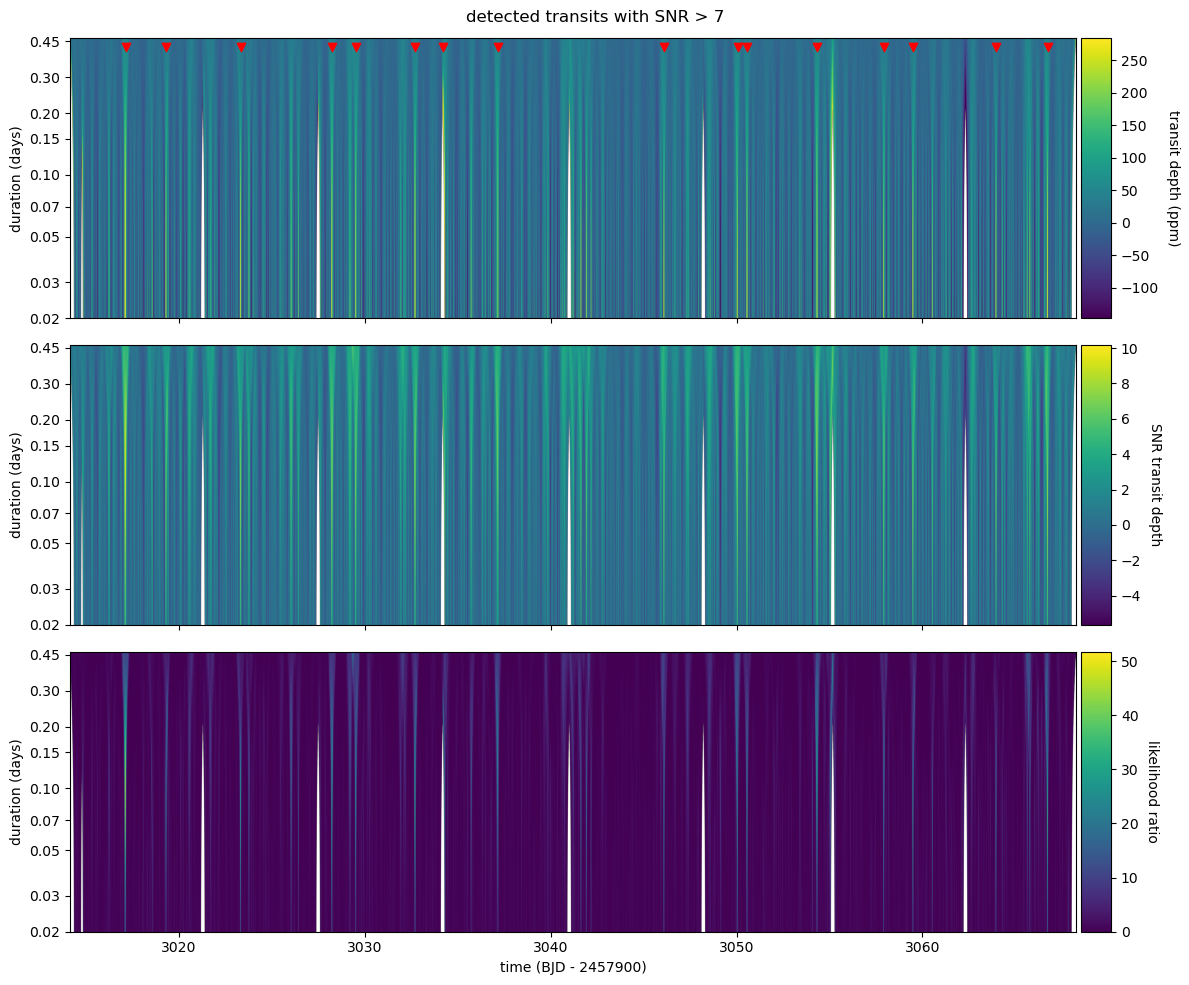

In [11]:
clip = 0.2
depth = linear_result.depth_array
depth_error = np.sqrt(linear_result.depth_variance_array)
lrat = linear_result.like_ratio_array
times = linear_result.light_curve.time
kwargs = {
    'aspect': 'auto',
    'cmap': 'viridis',
    'origin': 'lower',
    'extent': [times.min(), times.max(), 0, linear_result.duration_array.size-1]
}

fig, ax2 = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=False, figsize=(12, 10))

# depth panel
divider = make_axes_locatable(ax2[0])
cax0 = divider.append_axes('right', size='3%', pad=0.05)
vmin, vmax = np.nanpercentile(depth*1e6, [clip, 100-clip])
im0 = ax2[0].imshow(depth * 1e6, vmin=vmin, vmax=vmax, **kwargs)
fig.colorbar(im0, cax=cax0, orientation='vertical')
cax0.get_yaxis().labelpad = 15
cax0.set_ylabel('transit depth (ppm)', rotation=270)
plt.sca(cax0)

# SNR panel
divider = make_axes_locatable(ax2[1])
cax1 = divider.append_axes('right', size='3%', pad=0.05)
im1 = ax2[1].imshow(depth/depth_error, **kwargs)
fig.colorbar(im1, cax=cax1, orientation='vertical')
cax1.get_yaxis().labelpad = 15
cax1.set_ylabel('SNR transit depth', rotation=270)

# LR panel
divider = make_axes_locatable(ax2[2])
cax2 = divider.append_axes('right', size='3%', pad=0.05)
im2 = ax2[2].imshow(lrat, **kwargs)
fig.colorbar(im2, cax=cax2, orientation='vertical')
cax2.get_yaxis().labelpad = 15
cax2.set_ylabel('likelihood ratio', rotation=270)

# axis labels
ax2[2].set_xlabel(r"time (BJD - 2457900)")
for ax in ax2:
    ax.set_ylabel("duration (days)")
    plt.sca(ax)
    plt.yticks(yt_loc, yt_lab)

# show where the detected transits were
transit_times = [transit.t0 for transit in transits]
ax2[0].scatter(transit_times, [linear_result.duration_array.size-2]*len(transit_times), marker='v', color='r')

plt.suptitle("detected transits with SNR > 7")
plt.tight_layout()
plt.show()

## period search

In [12]:
period_result = td.period_search()

commencing periodic signal search
testing 5432 periods from 6.02e-01 to 2.68e+01 days


  0%|          | 0/5432 [00:00<?, ?it/s]

completed in 3.031 seconds


### extract significant periodic signals

In [13]:
periodic_signals = period_result.get_transits_above_snr_threshold(10)

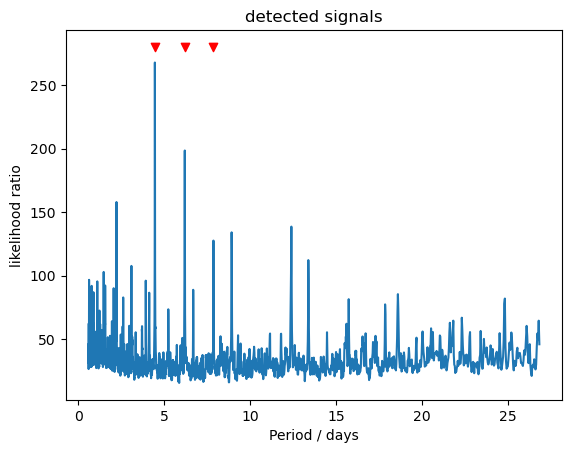

In [14]:
plt.plot(period_result.period_array, period_result.like_ratio_array)
# show where the detected transits were
periods = [signal.period for signal in periodic_signals]
plt.scatter(periods, [280]*len(periods), marker='v', color='r')
plt.xlabel("Period / days")
plt.ylabel("likelihood ratio")
plt.title("detected signals")
plt.show()

In [15]:
for transit in periodic_signals:
    print(transit)

Transit(
    t0=3014.855
    duration=0.076
    depth=1.899e-04
    depth_error=8.206e-06
    period=4.465103568398068
    SNR=23.14
)
Transit(
    t0=3017.110
    duration=0.063
    depth=2.140e-04
    depth_error=1.074e-05
    period=6.205637185446982
    SNR=19.92
)
Transit(
    t0=3018.567
    duration=0.063
    depth=1.906e-04
    depth_error=1.193e-05
    period=7.872858009218063
    SNR=15.97
)
